In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, SimpleRNN, Dropout


In [2]:
import yfinance as yf

data = yf.download("GOOG", start="2015-01-01", end="2024-12-31")
data.head()

/tmp/ipykernel_16378/984580163.py:3: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download("GOOG", start="2015-01-01", end="2024-12-31")
[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,GOOG,GOOG,GOOG,GOOG,GOOG
Date,,,,,
2015-01-02,25.955559,26.275053,25.920445,26.163278,28951268
2015-01-05,25.414497,25.931818,25.374438,25.878899,41196796
2015-01-06,24.825464,25.528497,24.780460,25.470385,57998800
2015-01-07,24.782932,25.086796,24.711219,25.074728,41301082
2015-01-08,24.861078,24.900644,24.283419,24.629124,67071641


In [3]:
dataset = data[['Close']]
dataset.head()

Price,Close
Ticker,GOOG
Date,
2015-01-02,25.955559
2015-01-05,25.414497
2015-01-06,24.825464
2015-01-07,24.782932
2015-01-08,24.861078


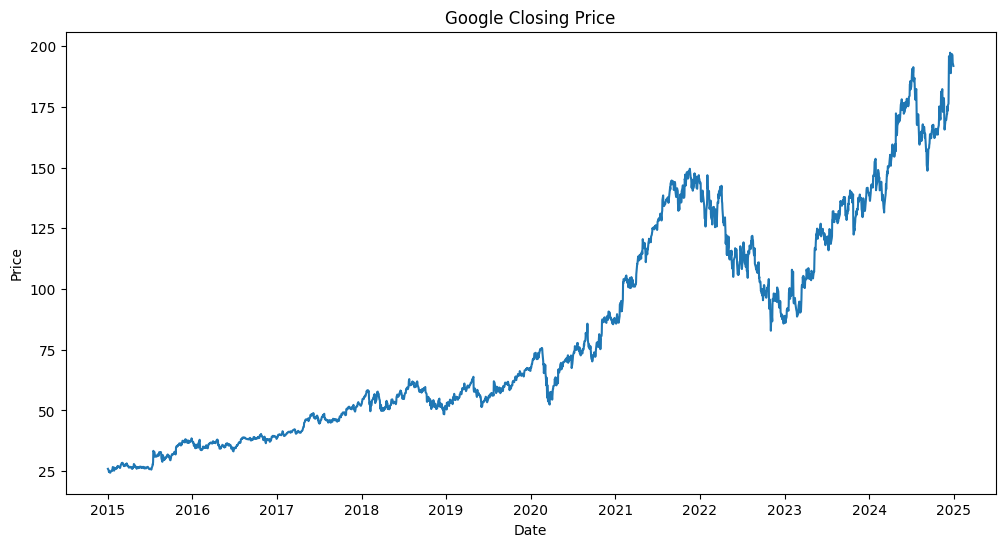

In [4]:
plt.figure(figsize=(12,6))
plt.plot(dataset)
plt.title("Google Closing Price")
plt.xlabel("Date")
plt.ylabel("Price")
plt.show()

In [5]:
scaler = MinMaxScaler(feature_range=(0,1))
scaled_data = scaler.fit_transform(dataset)

In [6]:
X_train = []
y_train = []

for i in range(60, len(scaled_data)):
    X_train.append(scaled_data[i-60:i, 0])
    y_train.append(scaled_data[i, 0])

X_train = np.array(X_train)
y_train = np.array(y_train)

In [7]:
X_train = np.reshape(X_train, (X_train.shape[0], X_train.shape[1], 1))
print(X_train.shape)

(2455, 60, 1)


In [8]:
model = Sequential()

model.add(SimpleRNN(units=50, return_sequences=True, input_shape=(X_train.shape[1],1)))
model.add(Dropout(0.2))

model.add(SimpleRNN(units=50))
model.add(Dropout(0.2))

model.add(Dense(units=1))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [9]:
model.compile(optimizer='adam', loss='mean_squared_error')

In [10]:
history = model.fit(X_train, y_train, epochs=20, batch_size=32)

Epoch 1/20
77/77 ━━━━━━━━━━━━━━━━━━━━ 4s 22ms/step - loss: 0.0457
Epoch 2/20
77/77 ━━━━━━━━━━━━━━━━━━━━ 2s 22ms/step - loss: 0.0130
Epoch 3/20
77/77 ━━━━━━━━━━━━━━━━━━━━ 2s 22ms/step - loss: 0.0074
Epoch 4/20
77/77 ━━━━━━━━━━━━━━━━━━━━ 2s 22ms/step - loss: 0.0058
Epoch 5/20
77/77 ━━━━━━━━━━━━━━━━━━━━ 3s 35ms/step - loss: 0.0047
Epoch 6/20
77/77 ━━━━━━━━━━━━━━━━━━━━ 4s 24ms/step - loss: 0.0043
Epoch 7/20
77/77 ━━━━━━━━━━━━━━━━━━━━ 2s 25ms/step - loss: 0.0036
Epoch 8/20
77/77 ━━━━━━━━━━━━━━━━━━━━ 2s 23ms/step - loss: 0.0031
Epoch 9/20
77/77 ━━━━━━━━━━━━━━━━━━━━ 2s 24ms/step - loss: 0.0028
Epoch 10/20
77/77 ━━━━━━━━━━━━━━━━━━━━ 4s 39ms/step - loss: 0.0025
Epoch 11/20
77/77 ━━━━━━━━━━━━━━━━━━━━ 4s 24ms/step - loss: 0.0024
Epoch 12/20
77/77 ━━━━━━━━━━━━━━━━━━━━ 2s 26ms/step - loss: 0.0025
Epoch 13/20
77/77 ━━━━━━━━━━━━━━━━━━━━ 2s 22ms/step - loss: 0.0021
Epoch 14/20
77/77 ━━━━━━━━━━━━━━━━━━━━ 4s 38ms/step - loss: 0.0018
Epoch 15/20
77/77 ━━━━━━━━━━━━━━━━━━━━ 2s 25ms/step - loss: 0.0018
Epoc

In [11]:
predicted = model.predict(X_train)
predicted = scaler.inverse_transform(predicted)

real = scaler.inverse_transform(y_train.reshape(-1,1))

77/77 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step


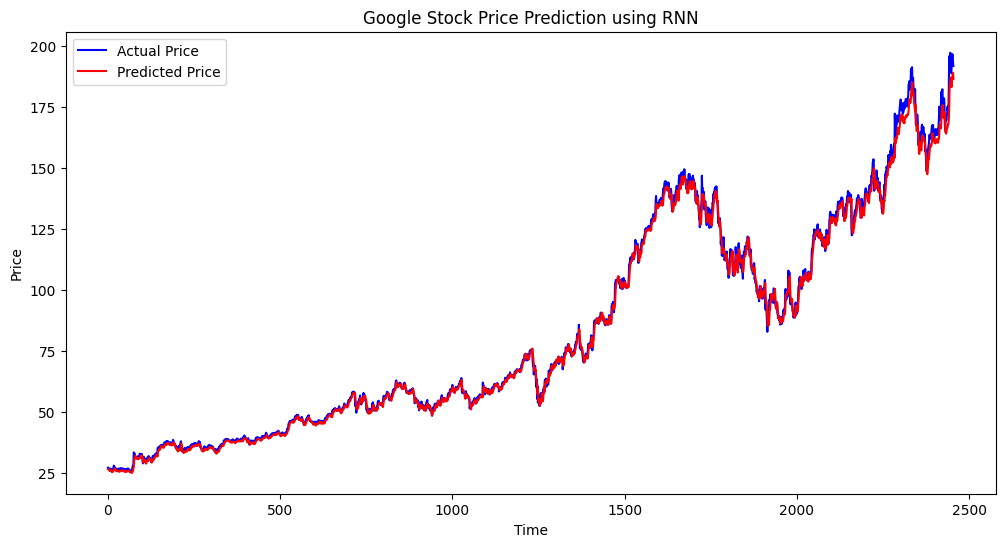

In [12]:
plt.figure(figsize=(12,6))
plt.plot(real, color='blue', label='Actual Price')
plt.plot(predicted, color='red', label='Predicted Price')
plt.title("Google Stock Price Prediction using RNN")
plt.xlabel("Time")
plt.ylabel("Price")
plt.legend()
plt.show()

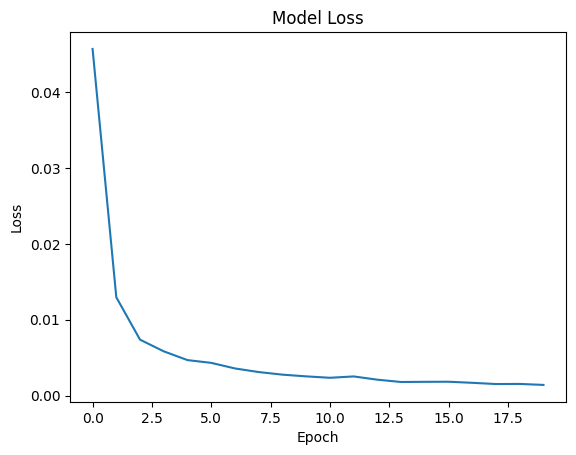

In [14]:
plt.plot(history.history['loss'])
plt.title("Model Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()